In [1]:
import os
import pandas as pd
import cv2
from tqdm import tqdm

In [2]:
import os
os.listdir('/kaggle/input')

['datasets']

#  1. Image Preprocessing

In [3]:
from skimage.morphology import remove_small_objects, disk, binary_dilation
from skimage.filters import frangi
from skimage.exposure import rescale_intensity
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def bone_window(img):
    """Apply bone windowing with percentile-based contrast stretching"""
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (0.5, 99.5))
    img = np.clip(img, p1, p99)
    if p99 - p1 > 0:
        img = (img - p1) / (p99 - p1)
    return img

def clahe(img):
    """Apply Contrast Limited Adaptive Histogram Equalization"""
    img8 = (img * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img8) / 255.0

def enhance_bones(img, bone_type='general'):
    """Apply Frangi filter to enhance bone structures"""
    if bone_type == 'fine':
        sigmas = np.arange(0.5, 4, 0.5)  # Smaller bones
    elif bone_type == 'thick':
        sigmas = np.arange(2, 10, 1)  # Larger bones
    else:
        sigmas = np.arange(0.5, 8, 0.5)  # Default - wider range

    v = frangi(img, sigmas=sigmas, black_ridges=False, alpha=0.5, beta=0.5, gamma=15)

    # More aggressive rescaling
    v = rescale_intensity(v, in_range='image', out_range=(0, 1))

    # Apply gamma correction to boost the response
    v = np.power(v, 0.7)

    return v

def make_bone_mask(bone_map, method='adaptive', percentile=50, min_size=500):
    """Create binary mask of bone regions"""
    if method == 'adaptive':
        # Use a much lower threshold - 50th percentile instead of 75th
        t = np.percentile(bone_map[bone_map > 0], percentile) if np.any(bone_map > 0) else 0
        mask = bone_map > t
    elif method == 'otsu':
        bone_8bit = (bone_map * 255).astype(np.uint8)
        # Apply Otsu on non-zero values only
        non_zero = bone_8bit[bone_8bit > 0]
        if len(non_zero) > 0:
            thresh_val = cv2.threshold(non_zero, 0, 255, cv2.THRESH_OTSU)[0]
            # Use a fraction of Otsu threshold for more sensitive detection
            mask = bone_8bit > (thresh_val * 0.5)
        else:
            mask = bone_8bit > 0
    else:  # 'percentile'
        t = np.percentile(bone_map, percentile)
        mask = bone_map > t

    
    if np.any(mask):
        mask = remove_small_objects(mask, min_size)
        # Slight dilation to connect nearby bone regions
        mask = binary_dilation(mask, disk(2))

    return mask

def process_xray(img_path,
                 bone_type='general',
                 mask_method='adaptive',
                 mask_percentile=50,
                 min_object_size=500):

    # Read image
    original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if original_img is None:
        return None

    # Validate image size
    if original_img.shape[0] < 100 or original_img.shape[1] < 100:
        print(f" Image too small: {img_path}")
        return None

    # Processing pipeline - simplified for better results
    processed_img = bone_window(original_img)
    processed_img = clahe(processed_img)

    # Apply Frangi filter
    bones = enhance_bones(processed_img, bone_type=bone_type)

    # Create mask with more sensitive thresholding
    mask = make_bone_mask(bones, method=mask_method,
                         percentile=mask_percentile,
                         min_size=min_object_size)

    bone_only = bones * mask

    return {
        'original': original_img,
        'bones': bones,
        'bone_only': bone_only,
        'mask': mask,
        'processed': processed_img
    }


# 2. Build Preprocessed Dataset

In [4]:
import os
from pathlib import Path
import cv2
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm



# ⚠️ CHANGE "mura-dataset" to your real Kaggle dataset folder name
BASE_PATH = "/kaggle/input/datasets/farahbenrejab/mura-dataset/MURA-v1.1"
OUTPUT_DIR = "/kaggle/working/MURA_ELBOW_PREPROCESSED"

os.makedirs(OUTPUT_DIR, exist_ok=True)


train_df = pd.read_csv(
    os.path.join(BASE_PATH, "train_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)

valid_df = pd.read_csv(
    os.path.join(BASE_PATH, "valid_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)


train_df = train_df[train_df["study_path"].str.contains("XR_ELBOW")].reset_index(drop=True)
valid_df = valid_df[valid_df["study_path"].str.contains("XR_ELBOW")].reset_index(drop=True)

print(f"Train elbow studies: {len(train_df)}")
print(f"Valid elbow studies: {len(valid_df)}")


def process_study(args):
    row, split = args
    saved_files = []

    study_path = row["study_path"]

    study_dir = os.path.join(
        BASE_PATH,
        study_path.replace("MURA-v1.1/", "")
    )

    if not os.path.exists(study_dir):
        print(f"Missing study folder: {study_dir}")
        return saved_files

    for img_name in os.listdir(study_dir):
        if not img_name.lower().endswith(".png"):
            continue

        img_path = os.path.join(study_dir, img_name)

        
        enhanced_dict = process_xray(
            img_path,
            bone_type="general",
            mask_method="adaptive",
            mask_percentile=50,
            min_object_size=500
        )

        if enhanced_dict is None:
            continue

        processed = enhanced_dict["processed"]

        # Normalize safely
        if np.max(processed) > 0:
            processed = (processed / np.max(processed) * 255).astype(np.uint8)
        else:
            processed = (processed * 255).astype(np.uint8)

        processed = cv2.resize(processed, (224, 224))

        relative_study_path = study_path.replace("MURA-v1.1/", "")

        out_path = (
            Path(OUTPUT_DIR)
            / "MURA-v1.1"
            / split
            / relative_study_path
            / img_name
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), processed)

        saved_files.append(str(out_path))

    return saved_files

def build_dataset_parallel(df, split, max_workers=2):  # ↓ reduced for Kaggle
    all_saved = []
    tasks = [(row, split) for _, row in df.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for saved in tqdm(
            executor.map(process_study, tasks),
            total=len(tasks),
            desc=f"Processing {split}"
        ):
            all_saved.extend(saved)

    return all_saved


saved_train = build_dataset_parallel(train_df, "train", max_workers=2)
saved_valid = build_dataset_parallel(valid_df, "valid", max_workers=2)

print("🎉 DONE")
print(f"Train images: {len(saved_train)}")
print(f"Valid images: {len(saved_valid)}") 

Train elbow studies: 1754
Valid elbow studies: 158


Processing valid: 100%|██████████| 158/158 [06:50<00:00,  2.60s/it]

🎉 DONE
Train images: 4931
Valid images: 465


In [5]:
!apt-get install tree -qq

Selecting previously unselected package tree.
(Reading database ... 129073 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


# 3. Dataset Overview & Label Generation

In [6]:
import os
import pandas as pd




# If you already preprocessed and saved inside /kaggle/working/
BASE = "/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1"

# Original MURA dataset location (inside Kaggle input)
BASE_ORIGINAL = "/kaggle/input/datasets/farahbenrejab/mura-dataset/MURA-v1.1"

train_csv = os.path.join(BASE_ORIGINAL, "train_labeled_studies.csv")
valid_csv = os.path.join(BASE_ORIGINAL, "valid_labeled_studies.csv")



train_df = pd.read_csv(train_csv, header=None, names=["study_path", "label"])
valid_df = pd.read_csv(valid_csv, header=None, names=["study_path", "label"])



train_df = train_df[train_df.study_path.str.contains("XR_ELBOW")].reset_index(drop=True)
valid_df = valid_df[valid_df.study_path.str.contains("XR_ELBOW")].reset_index(drop=True)



for df in [train_df, valid_df]:
    df["patient"] = df.study_path.apply(lambda x: x.split("/")[2])
    df["study"] = df.study_path.apply(lambda x: x.split("/")[3])

train_df["split"] = "train"
valid_df["split"] = "valid"

all_df = pd.concat([train_df, valid_df]).reset_index(drop=True)

print("✅ Done")
print(all_df.head())

✅ Done
                                          study_path  label   patient  \
0  MURA-v1.1/train/XR_ELBOW/patient04903/study1_p...      1  XR_ELBOW   
1  MURA-v1.1/train/XR_ELBOW/patient04904/study1_p...      1  XR_ELBOW   
2  MURA-v1.1/train/XR_ELBOW/patient04905/study1_p...      1  XR_ELBOW   
3  MURA-v1.1/train/XR_ELBOW/patient04906/study1_p...      1  XR_ELBOW   
4  MURA-v1.1/train/XR_ELBOW/patient04907/study1_p...      1  XR_ELBOW   

          study  split  
0  patient04903  train  
1  patient04904  train  
2  patient04905  train  
3  patient04906  train  
4  patient04907  train  


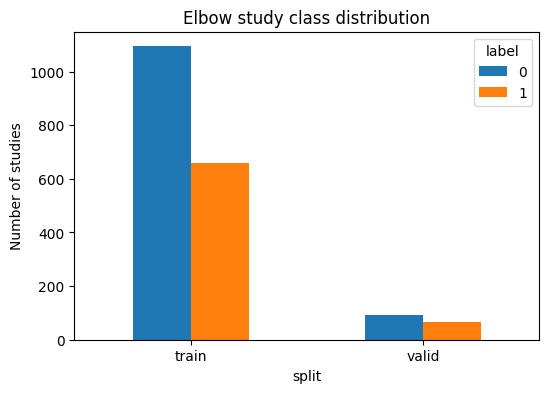

In [7]:
import matplotlib.pyplot as plt

counts = all_df.groupby(["split", "label"]).size().unstack()

counts.plot(kind="bar", figsize=(6,4))
plt.title("Elbow study class distribution")
plt.ylabel("Number of studies")
plt.xticks(rotation=0)
plt.show()


In [8]:
import os
import shutil

# Define the "oops" path and the "target" path
wrong_path = '/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1/train/train'
correct_base = '/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1'

if os.path.exists(wrong_path):
    
    for folder in os.listdir(wrong_path):
        src = os.path.join(wrong_path, folder)
        dst = os.path.join(correct_base, 'train', folder)
        shutil.move(src, dst)
    
   
    os.rmdir(wrong_path)
    print("Folders reorganized successfully!")
else:
    print("Path not found. Double-check your folder names using !ls -R")

Folders reorganized successfully!


In [9]:
import os
import shutil


wrong_path = '/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1/valid/valid'
correct_base = '/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1'

if os.path.exists(wrong_path):
   
    for folder in os.listdir(wrong_path):
        src = os.path.join(wrong_path, folder)
        dst = os.path.join(correct_base, 'valid', folder)
        shutil.move(src, dst)
    
  
    os.rmdir(wrong_path)
    print("Folders reorganized successfully!")
else:
    print("Path not found. Double-check your folder names using !ls -R")

Folders reorganized successfully!


In [10]:
import os
import csv

ROOT = "/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1"

def build_csv(split, out_csv):
    rows = []

    base = os.path.join(ROOT, split, "XR_ELBOW")

    for patient in sorted(os.listdir(base)):
        patient_dir = os.path.join(base, patient)
        if not os.path.isdir(patient_dir):
            continue

        for study in sorted(os.listdir(patient_dir)):
            study_dir = os.path.join(patient_dir, study)
            if not os.path.isdir(study_dir):
                continue

            # Label from folder name
            if "positive" in study.lower():
                label = 1
            elif "negative" in study.lower():
                label = 0
            else:
                print("Skipping (no label in name):", study_dir)
                continue

            mura_path = f"MURA-v1.1/{split}/XR_ELBOW/{patient}/{study}"
            rows.append([mura_path, label])

    # Save CSV
    with open(out_csv, "w", newline="") as f:
        writer = csv.writer(f)
        for r in rows:
            writer.writerow(r)

    print(f"{split}: {len(rows)} studies written → {out_csv}")


# Generate both
build_csv("train", "/kaggle/working/MURA_ELBOW_PREPROCESSED/train_labeled_studies.csv")
build_csv("valid", "/kaggle/working/MURA_ELBOW_PREPROCESSED/valid_labeled_studies.csv")

train: 1754 studies written → /kaggle/working/MURA_ELBOW_PREPROCESSED/train_labeled_studies.csv
valid: 158 studies written → /kaggle/working/MURA_ELBOW_PREPROCESSED/valid_labeled_studies.csv


# 4. Model Definition

In [11]:
!pip install torch torchvision tqdm pandas opencv-python

In [12]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import cv2
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [13]:
DATA_ROOT = "/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1"
CSV_ROOT  = "/kaggle/working/MURA_ELBOW_PREPROCESSED"

TRAIN_CSV = os.path.join(CSV_ROOT, "train_labeled_studies.csv")
VALID_CSV = os.path.join(CSV_ROOT, "valid_labeled_studies.csv")


In [14]:
class MuraelbowMIL(Dataset):
    def __init__(self, csv_file, split, transform=None):
        self.df = pd.read_csv(csv_file, header=None, names=["study_path","label"])
        self.df = self.df[self.df.study_path.str.contains("XR_ELBOW")]
        self.split = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = torch.tensor(row.label, dtype=torch.float32)

        rel = row.study_path.replace("MURA-v1.1/", "")
        study_dir = os.path.join(DATA_ROOT, self.split, rel.split("/",1)[1])

        images = []
        for f in os.listdir(study_dir):
            if f.endswith(".png"):
                img = cv2.imread(os.path.join(study_dir,f), cv2.IMREAD_GRAYSCALE)
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                if self.transform:
                    img = self.transform(img)
                images.append(img)

        bag = torch.stack(images)   # [N,3,224,224]
        return bag, label


# 5. Class Balancing

In [15]:
train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(10),
    T.RandomResizedCrop(224, scale=(0.9,1.0)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [16]:
train_ds = MuraelbowMIL(TRAIN_CSV, "train", train_tf)
valid_ds = MuraelbowMIL(VALID_CSV, "valid", val_tf)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader = DataLoader(valid_ds, batch_size=1, shuffle=False)

# 6. Training

In [17]:
class AttentionMIL(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v2(pretrained=True)
        self.feature_extractor = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_dim = 1280

        self.attention = nn.Sequential(
            nn.Linear(self.feat_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )

        self.classifier = nn.Linear(self.feat_dim, 1)

    def forward(self, x):   # x = [B=1, N, 3, H, W]
        x = x.squeeze(0)    # [N,3,H,W]

        feats = self.feature_extractor(x)
        feats = self.pool(feats).view(feats.size(0), -1)   # [N,1280]

        A = self.attention(feats)          # [N,1]
        A = torch.softmax(A, dim=0)        # attention weights

        bag_feat = torch.sum(A * feats, dim=0)   # weighted sum
        out = self.classifier(bag_feat)

        return out, A

In [18]:
import os

# Define your root directory
root_dir = '/kaggle/working/MURA_ELBOW_PREPROCESSED/MURA-v1.1/train/XR_ELBOW'

pos_count = 0
neg_count = 0


for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
           
            if 'positive' in root.lower():
                pos_count += 1
            elif 'negative' in root.lower():
                neg_count += 1

print(f"--- Dataset Summary for XR_ELBOW ---")
print(f"Positive (Abnormal) samples: {pos_count}")
print(f"Negative (Normal) samples:   {neg_count}")
print(f"Total images:                {pos_count + neg_count}")


if pos_count > 0:
    recommended_weight = neg_count / pos_count
    print(f"\nRecommended pos_weight: {recommended_weight:.4f}")

--- Dataset Summary for XR_ELBOW ---
Positive (Abnormal) samples: 2006
Negative (Normal) samples:   2925
Total images:                4931

Recommended pos_weight: 1.4581


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.tensor([1.458], device=device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


In [20]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = "/content/drive/MyDrive/MURA_ELBOW_CHECKPOINTS"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

resume_path = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")
best_auc = 0.0
start_epoch = 0



model = AttentionMIL().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

# 1.6 or 2.0 based on your previous class balance check
pos_weight = torch.tensor([2.0], device=device) 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

if os.path.exists(resume_path):
    print(f"Loading checkpoint: {resume_path}")
    checkpoint = torch.load(resume_path, map_location=device, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_auc = checkpoint.get('best_auc', 0.0)
    print(f"Resuming from epoch {start_epoch}. Previous Best AUC: {best_auc:.4f}")
else:
    print("No checkpoint found. Starting training from scratch.")


num_epochs = 15
for epoch in range(start_epoch, num_epochs):

 
    model.train()
    train_loss, train_acc = 0.0, 0.0
    

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for bags, label in train_pbar:
        bags, label = bags.to(device), label.to(device).float()

        optimizer.zero_grad()
        pred, _ = model(bags)
        loss = criterion(pred.view(-1), label.view(-1))
        
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pred_label = (torch.sigmoid(pred) > 0.5).float()
        train_acc += (pred_label.view(-1) == label.view(-1)).float().mean().item()

  
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Valid]")
        for bags, label in val_pbar:
            bags, label = bags.to(device), label.to(device).float()

            pred, _ = model(bags)
            loss = criterion(pred.view(-1), label.view(-1))
            val_loss += loss.item()

            probs = torch.sigmoid(pred)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(label.cpu().numpy())

    # Metrics calculation
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    all_preds = np.concatenate(all_preds).ravel()
    all_labels = np.concatenate(all_labels).ravel()
    auc = roc_auc_score(all_labels, all_preds)

    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUC: {auc:.4f}")

  
    checkpoint_state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': max(auc, best_auc),
    }
    
    torch.save(checkpoint_state, resume_path)
    
    if auc > best_auc:
        best_auc = auc
        best_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
        torch.save(checkpoint_state, best_path)
        print(f"🏆 New Best AUC! Saved to {best_path}")

print("\nTraining Complete!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 


No checkpoint found. Starting training from scratch.


Epoch 1/15 [Valid]: 100%|██████████| 158/158 [00:01<00:00, 83.69it/s]


...


Epoch 13 Summary:
Train Loss: 0.2434 | Val Loss: 2.2771 | Val AUC: 0.7143


Epoch 14/15 [Valid]: 100%|██████████| 158/158 [00:01<00:00, 89.49it/s]



Epoch 14 Summary:
Train Loss: 0.2079 | Val Loss: 1.5732 | Val AUC: 0.7684
🏆 New Best AUC! Saved to /content/drive/MyDrive/MURA_ELBOW_CHECKPOINTS/best_model.pth


Epoch 15/15 [Valid]: 100%|██████████| 158/158 [00:01<00:00, 85.98it/s]



Epoch 15 Summary:
Train Loss: 0.1959 | Val Loss: 1.7804 | Val AUC: 0.7680

Training Complete!


# 6. Training

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'all_labels' and 'all_preds' are already collected from your loop
# Convert probabilities to binary classes (0 or 1)
binary_preds = [1 if p > 0.5 else 0 for p in all_preds]

# Generate the confusion matrix
cm = confusion_matrix(all_labels, binary_preds)

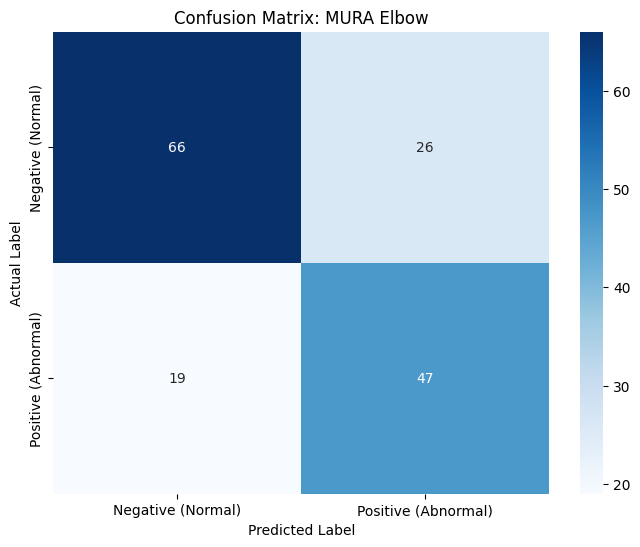

In [22]:
def plot_mura_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    
    # Define labels for MURA
    labels = ['Negative (Normal)', 'Positive (Abnormal)']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    
    plt.title('Confusion Matrix: MURA Elbow')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_mura_confusion_matrix(cm)

In [23]:
from sklearn.metrics import classification_report, cohen_kappa_score, precision_recall_fscore_support


threshold = 0.5  
binary_preds = (all_preds > threshold).astype(int)


print("\n" + "="*30)
print("      DETAILED EVALUATION")
print("="*30)
print(classification_report(all_labels, binary_preds, target_names=['Normal', 'Abnormal']))

# 3. Cohen's Kappa (MURA Standard)
kappa = cohen_kappa_score(all_labels, binary_preds)

# 4. Specificity (Recall of the Negative class)
# In medical terms, sensitivity = recall of positive class
# specificity = recall of negative class
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, binary_preds)
sensitivity = recall[1]
specificity = recall[0]

print(f"Cohen's Kappa Score: {kappa:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:         {specificity:.4f}")
print("="*30)


      DETAILED EVALUATION
              precision    recall  f1-score   support

      Normal       0.78      0.72      0.75        92
    Abnormal       0.64      0.71      0.68        66

    accuracy                           0.72       158
   macro avg       0.71      0.71      0.71       158
weighted avg       0.72      0.72      0.72       158

Cohen's Kappa Score: 0.4232
Sensitivity (Recall): 0.7121
Specificity:         0.7174


In [24]:
import cv2
import numpy as np
import torch
from PIL import Image

class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        # 1. Convert PIL Image to NumPy array
        img_np = np.array(img)

       
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)

       
        if len(img_np.shape) == 3:
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            lab_planes = list(cv2.split(lab))
            lab_planes[0] = clahe.apply(lab_planes[0])
            lab = cv2.merge(lab_planes)
            img_processed = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        else:
         
            img_processed = clahe.apply(img_np)

      
        return Image.fromarray(img_processed)

In [25]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)), # <-- Add it here!
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    ApplyCLAHE(clip_limit=2.0), # Same parameters as training
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [26]:
import os
import torch
import torch.nn as nn
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.metrics import roc_auc_score


def apply_clahe_to_batch(batch_tensor):
    batch_np = batch_tensor.cpu().numpy()
    enhanced_batch = []
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    for img in batch_np:
        for c in range(img.shape[0]):
            channel = (img[c] * 255).astype(np.uint8)
            img[c] = clahe.apply(channel) / 255.0
        enhanced_batch.append(img)
        
    return torch.from_numpy(np.array(enhanced_batch)).to(device).float()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ FIXED PATH (KAGGLE ONLY)
CHECKPOINT_DIR = "/kaggle/working/MURA_ELBOW_CHECKPOINTS"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

resume_path = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")


print(f" Checkpoints will be saved in: {CHECKPOINT_DIR}")

best_auc = 0.0
start_epoch = 0


model = AttentionMIL().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

pos_weight = torch.tensor([1.4581], device=device) 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


if os.path.exists(resume_path):
    print(f" Loading weights from {resume_path}")
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Weights loaded (fresh training restart).")
else:
    print(" No checkpoint found. Starting from scratch.")

# ---------------- TRAINING LOOP ----------------
num_epochs = 15
for epoch in range(start_epoch, num_epochs):

    model.train()
    train_loss = 0.0

    for bags, label in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        bags, label = bags.to(device), label.to(device).float()

        optimizer.zero_grad()
        pred, _ = model(bags)
        loss = criterion(pred.view(-1), label.view(-1))
        
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

 
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for bags, label in tqdm(val_loader, desc=f"Epoch {epoch+1} [Valid]"):
            bags, label = bags.to(device), label.to(device).float()

            pred, _ = model(bags)
            loss = criterion(pred.view(-1), label.view(-1))
            val_loss += loss.item()

            probs = torch.sigmoid(pred)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(label.cpu().numpy())

    # Metrics
    all_preds = np.concatenate(all_preds).ravel()
    all_labels = np.concatenate(all_labels).ravel()
    auc = roc_auc_score(all_labels, all_preds)

    print(f"\n📊 Epoch {epoch+1} → AUC: {auc:.4f}")

    # ---------------- SAVE ----------------
    checkpoint_state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': max(auc, best_auc),
    }

  
    torch.save(checkpoint_state, resume_path)
    print(f"💾 Saved: {resume_path}")

   
    if auc > best_auc:
        best_auc = auc
        best_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
        torch.save(checkpoint_state, best_path)
        print(f"🏆 Best model saved: {best_path}")

print("\n Training Complete!")


print("\n Files inside checkpoint folder:")
print(os.listdir(CHECKPOINT_DIR))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


📂 Checkpoints will be saved in: /kaggle/working/MURA_ELBOW_CHECKPOINTS
🚀 No checkpoint found. Starting from scratch.


Epoch 1 [Valid]: 100%|██████████| 158/158 [00:01<00:00, 88.63it/s]



📊 Epoch 1 → AUC: 0.7319
💾 Saved: /kaggle/working/MURA_ELBOW_CHECKPOINTS/last_checkpoint.pth
🏆 Best model saved: /kaggle/working/MURA_ELBOW_CHECKPOINTS/best_model.pth


Epoch 2 [Valid]: 100%|██████████| 158/158 [00:01<00:00, 83.87it/s]


...


📊 Epoch 13 → AUC: 0.7895
💾 Saved: /kaggle/working/MURA_ELBOW_CHECKPOINTS/last_checkpoint.pth
🏆 Best model saved: /kaggle/working/MURA_ELBOW_CHECKPOINTS/best_model.pth


Epoch 14 [Valid]: 100%|██████████| 158/158 [00:01<00:00, 87.52it/s]



📊 Epoch 14 → AUC: 0.8048
💾 Saved: /kaggle/working/MURA_ELBOW_CHECKPOINTS/last_checkpoint.pth
🏆 Best model saved: /kaggle/working/MURA_ELBOW_CHECKPOINTS/best_model.pth


Epoch 15 [Valid]: 100%|██████████| 158/158 [00:01<00:00, 87.83it/s]



📊 Epoch 15 → AUC: 0.7862
💾 Saved: /kaggle/working/MURA_ELBOW_CHECKPOINTS/last_checkpoint.pth

✅ Training Complete!

📂 Files inside checkpoint folder:
['best_model.pth', 'last_checkpoint.pth']


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


binary_preds = [1 if p > 0.5 else 0 for p in all_preds]


cm = confusion_matrix(all_labels, binary_preds)

# 9. Final Evaluation

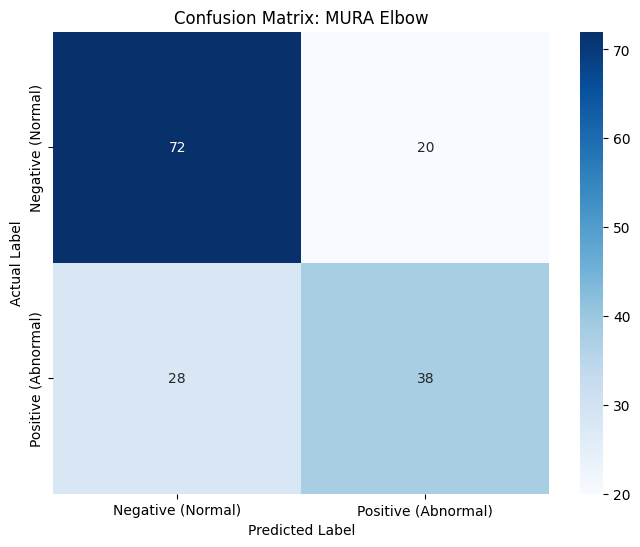

In [28]:
def plot_mura_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    

    labels = ['Negative (Normal)', 'Positive (Abnormal)']
    
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    
    plt.title('Confusion Matrix: MURA Elbow')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_mura_confusion_matrix(cm)

# 10. Export Checkpoints

In [30]:
import shutil

shutil.make_archive(
    "/kaggle/working/checkpoints_backup",
    "zip",
    "/kaggle/working/MURA_ELBOW_CHECKPOINTS"
)

print(" Done! Download it from the Output panel.")

✅ Done! Download it from the Output panel.
